In [35]:
# === Development Environment ===
"""
Python version:       3.10.15 
pandas version:       2.2.3
numpy version:        1.26.4
scikit-learn version: 1.5.1
matplotlib version: 3.9.1
"""

'\nPython version:       3.10.15 \npandas version:       2.2.3\nnumpy version:        1.26.4\nscikit-learn version: 1.5.1\nmatplotlib version: 3.9.1\n'

In [36]:
import pandas as pd
import sys
import numpy as np
from sklearn.metrics import roc_auc_score, precision_recall_curve, auc, f1_score, precision_score, accuracy_score
from sklearn.utils import resample
import os


import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from math import pi
from sklearn.metrics import average_precision_score

In [37]:
mRNA_result = pd.read_csv("../analysis/mRNA_pred.csv")
mRNA_result

,pMHC,patientID,Peptide,MHC,MMS_Cluster,Label,ImmunoMTL_score,BigMHC_IM,PRIME_score,PRIME_rank,munis,netMHCpan_score,netMHCpan_rank,mhcflurry_presentation_score,mhcflurry_presentation_rank
0,ITVNASRPQPFHLA-A*32:01,1,ITVNASRPQPF,HLA-A*32:01,0.0,0,9.296952e-01,0.000514,0.002020,19.170,0.151489,0.0126,4.6814,0.029584,8.269212
1,RLAAAVRFHLA-A*32:01,5,RLAAAVRF,HLA-A*32:01,0.0,0,2.207086e-08,0.006755,0.004967,8.816,0.271729,0.0734,1.5100,0.121985,2.557500
2,AVMHLDHSDTIHLA-A*32:01,5,AVMHLDHSDTI,HLA-A*32:01,0.0,0,4.035173e-01,0.000256,0.014185,3.145,0.095215,0.0201,3.6059,0.028207,8.545326
3,TEYKLVVVGAVHLA-B*41:01,1,TEYKLVVVGAV,HLA-B*41:01,1.0,0,9.999158e-01,0.005845,0.001803,20.529,0.219482,0.0498,1.9947,0.310056,1.330625
4,CDSHGLGKNPIHLA-B*41:01,1,CDSHGLGKNPI,HLA-B*41:01,1.0,0,2.249859e-06,0.047019,0.000681,40.298,0.005642,0.0000,45.3333,0.027011,9.155353
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
217,LADLLNPIHLA-C*08:02,29,LADLLNPI,HLA-C*08:02,3.0,1,9.113949e-01,0.280507,0.014621,2.698,0.526855,0.1393,0.7491,0.631520,0.558315
218,MSCRVGEELHLA-A*68:02,29,MSCRVGEEL,HLA-A*68:02,0.0,0,4.563048e-04,0.542159,0.023657,1.844,0.493896,0.0467,2.8674,0.115379,2.646576
219,DTYVPTSDYKHLA-A*68:02,29,DTYVPTSDYK,HLA-A*68:02,0.0,0,2.675578e-05,0.644923,0.039359,1.001,0.285400,0.0139,5.8400,0.170581,2.042935
220,THESDLPPSDKHLA-A*68:02,29,THESDLPPSDK,HLA-A*68:02,0.0,0,9.537110e-01,0.212156,0.000548,44.581,0.312988,0.0000,55.0000,0.013242,17.305598


In [38]:
pos_mRNA_result = mRNA_result[mRNA_result["Label"]==1]
pos_mRNA_result.groupby("patientID").count()

,pMHC,Peptide,MHC,MMS_Cluster,Label,ImmunoMTL_score,BigMHC_IM,PRIME_score,PRIME_rank,munis,netMHCpan_score,netMHCpan_rank,mhcflurry_presentation_score,mhcflurry_presentation_rank
patientID,,,,,,,,,,,,,,
5,1,1,1,1,1,1,1,1,1,1,1,1,1,1
6,1,1,1,1,1,1,1,1,1,1,1,1,1,1
10,7,7,7,7,7,7,7,7,7,7,7,7,7,7
11,3,3,3,3,3,3,3,3,3,3,3,3,3,3
14,1,1,1,1,1,1,1,1,1,1,1,1,1,1
25,3,3,3,3,3,3,3,3,3,3,3,3,3,3
29,5,5,5,5,5,5,5,5,5,5,5,5,5,5


In [39]:
p10 = mRNA_result[mRNA_result["patientID"] == 10]
p11 = mRNA_result[mRNA_result["patientID"] == 11]
p25 = mRNA_result[mRNA_result["patientID"] == 25]
p29 = mRNA_result[mRNA_result["patientID"] == 29]

In [40]:
#accumulate prism
import matplotlib.pyplot as plt
prediction_columns = ['ImmunoMTL_score', 'BigMHC_IM', 'munis', 'PRIME_rank', 'netMHCpan_rank', 'mhcflurry_presentation_rank']
precision_at_k = {column: [] for column in prediction_columns}
avg_top_k = {}

def calculate_accumulated_precision(df, prediction_columns, k):
    #if prediction_columns == 'IMMpred':
        #df = df[df["EL_rank"]<2]
    #k = len(df[df["IMMpred"] >= 0.5])
    #print(k)
    precision_at_k_df = pd.DataFrame(index=range(1, k+1))
    acc_at_k_df = pd.DataFrame(index=range(1, k+1))
    tp_at_k_df = pd.DataFrame(index=range(1, k+1))

    for column in prediction_columns:
        # Sort the dataframe based on the model's predictions
        # Note: We need to sort ranks in ascending order, but scores in descending order
        aaaascending = True if 'rank' in column.lower() else False
        sorted_df = df.sort_values(by=column, ascending=aaaascending)

        # Calculate the accumulated precision at each k
        accumulated_precision = []
        true_positives = 0
        top_k_scores = []
        for i in range(k):
            if sorted_df.iloc[i]['Label'] == 1:
                true_positives += 1
            accumulated_precision.append(true_positives / (i+1))
            top_k_scores.append(true_positives / (i+1))
            
        precision_at_k_df[column] = accumulated_precision
        # Calculate and store median of top k predictions
        avg_top_k[column] = np.mean(top_k_scores)
        
        accumulated_acc = []
        true_positive_negative = 0
        for i in range(k):
            if sorted_df.iloc[i]['Label'] == sorted_df.iloc[i][column]:
                true_positive_negative += 1
            accuracy_at_k = true_positive_negative / (i+1)
            accumulated_acc.append(accuracy_at_k)
        acc_at_k_df[column] = accumulated_precision
        
        accumulated_tp = []
        true_positive = 0
        for i in range(k):
            if sorted_df.iloc[i]['Label'] == 1:
                true_positive += 1
            accumulated_tp.append(true_positive)
        tp_at_k_df[column] = accumulated_tp

    return precision_at_k_df, acc_at_k_df, avg_top_k

In [41]:
def count_peptides_until_first_positive(df, prediction_columns):
    first_pos_index = {}

    for column in prediction_columns:
        # Sort predictions: lower is better for ranks, higher is better for scores
        ascending = True if 'rank' in column.lower() else False
        sorted_df = df.sort_values(by=column, ascending=ascending).reset_index(drop=True)

        # Find the index of the first positive label (Label == 1)
        first_positive_idx = sorted_df[sorted_df['Label'] == 1].index.min()

        # If there's no positive, return NaN
        if pd.isna(first_positive_idx):
            first_pos_index[column] = np.nan
        else:
            # Add 1 to make it human-readable (1-based index)
            first_pos_index[column] = first_positive_idx + 1

    return first_pos_index

In [42]:
# Number of top predictions to calculate precision for
top_k = 10

# Calculate the accumulated precision for each model up to top_k
precision_at_k_results, acc_at_k_results, avg_top_k = calculate_accumulated_precision(p10, prediction_columns, 10)
first_pos_index = count_peptides_until_first_positive(p10, prediction_columns)
print(precision_at_k_results)
print(avg_top_k)
print(acc_at_k_results)
print(first_pos_index)
# Output the results to a CSV file
#precision_at_k_results.to_csv('../analysis/p29_acc.csv', index_label='Top k predictions')
precision_at_k_results.to_csv("../analysis/mRNA_p10.csv", index = False)

    ImmunoMTL_score  BigMHC_IM     munis  PRIME_rank  netMHCpan_rank  \
1          1.000000   0.000000  1.000000    1.000000        1.000000   
2          1.000000   0.500000  1.000000    1.000000        1.000000   
3          0.666667   0.333333  0.666667    1.000000        1.000000   
4          0.750000   0.500000  0.750000    1.000000        1.000000   
5          0.800000   0.600000  0.600000    0.800000        1.000000   
6          0.833333   0.500000  0.666667    0.833333        0.833333   
7          0.857143   0.571429  0.714286    0.714286        0.714286   
8          0.750000   0.625000  0.750000    0.750000        0.625000   
9          0.666667   0.555556  0.666667    0.777778        0.555556   
10         0.600000   0.600000  0.600000    0.700000        0.600000   

    mhcflurry_presentation_rank  
1                      1.000000  
2                      0.500000  
3                      0.333333  
4                      0.500000  
5                      0.600000  
6  

In [43]:
# Number of top predictions to calculate precision for
top_k = 10

# Calculate the accumulated precision for each model up to top_k
precision_at_k_results, acc_at_k_results, avg_top_k = calculate_accumulated_precision(p11, prediction_columns, 10)
first_pos_index = count_peptides_until_first_positive(p11, prediction_columns)

print(precision_at_k_results)
print(avg_top_k)
print(acc_at_k_results)
print(first_pos_index)

# Output the results to a CSV file
precision_at_k_results.to_csv("../analysis/mRNA_p11.csv", index = False)

    ImmunoMTL_score  BigMHC_IM     munis  PRIME_rank  netMHCpan_rank  \
1          0.000000   0.000000  0.000000    0.000000        0.000000   
2          0.000000   0.500000  0.000000    0.000000        0.000000   
3          0.333333   0.333333  0.000000    0.333333        0.000000   
4          0.500000   0.250000  0.250000    0.250000        0.000000   
5          0.400000   0.200000  0.200000    0.200000        0.000000   
6          0.333333   0.166667  0.166667    0.166667        0.166667   
7          0.285714   0.142857  0.142857    0.142857        0.142857   
8          0.250000   0.250000  0.125000    0.125000        0.125000   
9          0.222222   0.222222  0.111111    0.111111        0.111111   
10         0.200000   0.200000  0.200000    0.200000        0.200000   

    mhcflurry_presentation_rank  
1                      0.000000  
2                      0.000000  
3                      0.000000  
4                      0.000000  
5                      0.200000  
6  

In [44]:
# Number of top predictions to calculate precision for
top_k = 10

# Calculate the accumulated precision for each model up to top_k
precision_at_k_results, acc_at_k_results, avg_top_k = calculate_accumulated_precision(p25, prediction_columns, 10)
first_pos_index = count_peptides_until_first_positive(p25, prediction_columns)

print(precision_at_k_results)
print(avg_top_k)
print(acc_at_k_results)
print(first_pos_index)

# Output the results to a CSV file
#precision_at_k_results.to_csv('../analysis/p29_acc.csv', index_label='Top k predictions')
precision_at_k_results.to_csv("../analysis/mRNA_p25.csv", index = False)

    ImmunoMTL_score  BigMHC_IM     munis  PRIME_rank  netMHCpan_rank  \
1          1.000000   0.000000  0.000000    0.000000        0.000000   
2          1.000000   0.000000  0.000000    0.500000        0.000000   
3          0.666667   0.000000  0.000000    0.333333        0.333333   
4          0.500000   0.250000  0.000000    0.250000        0.250000   
5          0.400000   0.200000  0.200000    0.200000        0.200000   
6          0.333333   0.166667  0.166667    0.166667        0.166667   
7          0.285714   0.142857  0.142857    0.142857        0.142857   
8          0.250000   0.125000  0.125000    0.125000        0.125000   
9          0.222222   0.222222  0.111111    0.111111        0.111111   
10         0.200000   0.200000  0.100000    0.200000        0.200000   

    mhcflurry_presentation_rank  
1                      0.000000  
2                      0.000000  
3                      0.000000  
4                      0.250000  
5                      0.200000  
6  

In [45]:
# Number of top predictions to calculate precision for
top_k = 10

# Calculate the accumulated precision for each model up to top_k
precision_at_k_results, acc_at_k_results, avg_top_k = calculate_accumulated_precision(p29, prediction_columns, 10)
first_pos_index = count_peptides_until_first_positive(p29, prediction_columns)

print(precision_at_k_results)
print(avg_top_k)
print(acc_at_k_results)
print(first_pos_index)

# Output the results to a CSV file
#precision_at_k_results.to_csv('../analysis/p29_acc.csv', index_label='Top k predictions')
precision_at_k_results.to_csv("../analysis/mRNA_p29.csv", index = False)

    ImmunoMTL_score  BigMHC_IM     munis  PRIME_rank  netMHCpan_rank  \
1          1.000000   0.000000  0.000000    0.000000        0.000000   
2          0.500000   0.000000  0.500000    0.500000        0.500000   
3          0.333333   0.333333  0.333333    0.333333        0.333333   
4          0.250000   0.250000  0.250000    0.250000        0.250000   
5          0.200000   0.400000  0.400000    0.200000        0.200000   
6          0.333333   0.333333  0.500000    0.166667        0.333333   
7          0.285714   0.285714  0.428571    0.142857        0.285714   
8          0.250000   0.250000  0.375000    0.125000        0.375000   
9          0.222222   0.333333  0.333333    0.111111        0.444444   
10         0.200000   0.400000  0.400000    0.200000        0.500000   

    mhcflurry_presentation_rank  
1                      1.000000  
2                      1.000000  
3                      0.666667  
4                      0.750000  
5                      0.600000  
6  

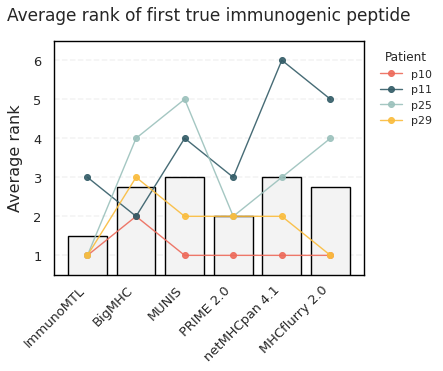

In [46]:
import os
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

plt.rcParams['pdf.fonttype'] = 42

# === CONFIG ===
output_dir = "../analysis/figures"
os.makedirs(output_dir, exist_ok=True)

# === COLOR PALETTE ===
custom_colors = ["#ed6a5a", "#335c67", "#9bc1bc", "#FABC3C"]

# === DATA ===
df = pd.DataFrame({
    "Patient": ["p10","p11","p25","p29"],
    "ImmunoMTL": [1,3,1,1],
    "BigMHC": [2,2,4,3],
    "MUNIS": [1,4,5,2],
    "PRIME 2.0": [1,3,2,2],
    "netMHCpan 4.1": [1,6,3,2],
    "MHCflurry 2.0": [1,5,4,1],
})

df_melt = df.melt(id_vars="Patient", var_name="Model", value_name="Rank")
order = ["ImmunoMTL", "BigMHC", "MUNIS", "PRIME 2.0", "netMHCpan 4.1", "MHCflurry 2.0"]

# === FIGURE ===
plt.figure(figsize=(6.5,5.5))
sns.set_style("whitegrid", {'axes.edgecolor': 'black'})  # ensure black edges
sns.set_context("talk")

# Barplot (mean ± SD)
sns.barplot(
    data=df_melt, x="Model", y="Rank",
    order=order,
    ci=None,
    color="#F3F3F3", edgecolor="black", linewidth=1.4
)

# Overlay patient lines
palette = sns.color_palette(custom_colors, n_colors=df["Patient"].nunique())
for (patient, sub), color in zip(df_melt.groupby("Patient"), palette):
    sub = sub.set_index("Model").loc[order].reset_index()
    plt.plot(sub["Model"], sub["Rank"],
             marker="o", markersize=6,
             linewidth=1.4, alpha=0.9, color=color, label=patient)

# === STYLE ===
ax = plt.gca()
ax.set_ylim(0.5, 6.5)
ax.set_yticks(range(1,7))
ax.set_yticklabels(range(1,7), fontsize=13)
ax.set_xticks(range(len(order)))
ax.set_xticklabels(order, rotation=45, ha="right", fontsize=13)
ax.tick_params(axis="x", length=5, width=1)

plt.ylabel("Average rank", fontsize=16, labelpad=10)
plt.xlabel("")
plt.title("Average rank of first true immunogenic peptide", fontsize=17, pad=20)
plt.grid(axis="y", linestyle="--", alpha=0.25)

# === BLACK BORDER FIX ===
for side in ["bottom", "left", "right", "top"]:
    ax.spines[side].set_visible(True)
    ax.spines[side].set_color("black")
    ax.spines[side].set_linewidth(1.4)

# === LEGEND ===
plt.legend(
    title="Patient", fontsize=11, title_fontsize=12,
    frameon=False, loc="upper left", bbox_to_anchor=(1.02,1)
)

plt.tight_layout()

# === SAVE ===
plt.savefig(os.path.join(output_dir, "first_hit_rank_barplot_blackborder.png"),
             dpi=300, transparent=False)
plt.savefig(os.path.join(output_dir, "first_hit_rank_barplot_blackborder.pdf"),
             dpi=300, transparent=False)

plt.show()
plt.close()

In [48]:
p6

,pMHC,patientID,Peptide,MHC,MMS_Cluster,Label,ImmunoMTL_score,BigMHC_IM,PRIME_score,PRIME_rank,munis,netMHCpan_score,netMHCpan_rank,mhcflurry_presentation_score,mhcflurry_presentation_rank
23,KSDPTEWAMYHLA-A*01:01,6,KSDPTEWAMY,HLA-A*01:01,3.0,0,9.941488e-01,0.280748,0.187934,0.036,0.996094,0.9729,0.0141,0.958816,0.035598
24,YSDVLSPTHAHLA-A*01:01,6,YSDVLSPTHA,HLA-A*01:01,3.0,0,1.200946e-03,0.027950,0.074883,0.287,0.892090,0.1102,1.2104,0.169449,2.051168
25,YSDFVKLQKHLA-A*01:01,6,YSDFVKLQK,HLA-A*01:01,3.0,1,4.720447e-05,0.152547,0.198499,0.029,0.937012,0.4206,0.3717,0.517711,0.783315
58,GSCLEDFWHLA-B*57:01,6,GSCLEDFW,HLA-B*57:01,2.0,0,3.313808e-10,0.153278,0.004597,9.423,0.193359,0.1866,1.9555,0.269595,1.482147
139,EVLMVLDNYHLA-A*26:01,6,EVLMVLDNY,HLA-A*26:01,0.0,0,6.846948e-08,0.007858,0.158430,0.116,0.963379,0.6804,0.0820,0.842389,0.212201
144,YASGHTTGIVHLA-C*12:03,6,YASGHTTGIV,HLA-C*12:03,0.0,0,9.999998e-01,0.043835,0.046546,1.022,0.681641,0.0640,1.1777,0.347936,1.204973
145,TEYKLVVVGAVHLA-C*12:03,6,TEYKLVVVGAV,HLA-C*12:03,0.0,0,9.999844e-01,0.001772,0.001924,19.084,0.001083,0.0000,56.6667,0.003891,99.286603
146,NALGYNSVSIHLA-C*12:03,6,NALGYNSVSI,HLA-C*12:03,0.0,0,1.625521e-05,0.003870,0.007485,6.350,0.024017,0.0014,10.1695,0.108219,2.760054
147,YLMEKAHSVSVHLA-C*12:03,6,YLMEKAHSVSV,HLA-C*12:03,0.0,0,3.741935e-04,0.005265,0.004941,8.970,0.127686,0.0052,5.5674,0.074011,3.679429
148,LAPPQLLIHLA-C*12:03,6,LAPPQLLI,HLA-C*12:03,0.0,0,9.999034e-01,0.018308,0.002314,17.190,0.189087,0.0252,2.3317,0.425051,0.994158
